<a href="https://colab.research.google.com/github/rejsik99/Pathvector-BGPStatus-Page/blob/main/Individual-Contest/Radar/Radar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/IOAI-official/IOAI-2025/blob/main/Individual-Contest/Radar/figs/IOAI-Logo.png?raw=1" alt="IOAI Logo" width="200" height="auto">

[IOAI 2025 (Beijing, China), Individual Contest](https://ioai-official.org/china-2025)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IOAI-official/IOAI-2025/blob/main/Individual-Contest/Radar/Radar.ipynb)

# Radar

## 1. Problem Description

Radar is a key technology in wireless communication, with widespread applications such as self-driving cars. It typically involves an antenna that transmits specific signals and receives their reflections from objects in the environment. By processing these signals, the system determines the angular direction, distance, and velocity of target objects.

In real-world applications, radar signal processing is challenging due to noise and reflections from non-target objects in the surroundings. For example, when attempting to detect pedestrians, the radar may also receive reflections from trees or other background objects, which can degrade accuracy. Your task is to use AI to analyze the signals received by the radar and identify the presence of a human at each position.

In this task, we provide an **indoor radar experiment dataset**, and your objective is to develop a model that performs **radar semantic segmentation**.


## 2. Dataset

To measure objects surrounding a radar, the following key parameters are used:

- **Range**: The straight-line distance between the radar and an object.
- **Azimuth**: The horizontal angle (left to right) between the radar and the object.
- **Elevation**: The vertical angle (up or down) of the object relative to the radar.
- **Velocity**: The speed at which the object is moving toward or away from the radar.

<img src="https://github.com/IOAI-official/IOAI-2025/blob/main/Individual-Contest/Radar/figs/Radar%20Fig%201.png?raw=1" width="300">


The radar data is processed into multiple **heatmaps**, each encoding the **received signal strength** at various positions and directions.

- **Static heatmaps** emphasize reflections from **stationary** objects.
- **Dynamic heatmaps** highlight changes caused by **moving** objects.

When no object is present at a specific location, the signal consists mostly of background noise and appears weak. In contrast, reflections from an object increase signal intensity, enabling detection of the object.

For example, the **static range-azimuth heatmap** represents signal strength across different distances (**range**) and horizontal angles (**azimuth**), mainly reflected by stationary objects.

Each sample in the dataset is stored in a `.mat.pt` file as a tensor of shape $7 \times 50 \times 181$, where:

- 7 is the number of maps (6 heatmaps + 1 semantic label map),
- 50 represents range bins (distance),
- 181 represents angular or velocity bins, covering angles from \-90° to \+90° in either the horizontal or vertical plane. You can assume that the velocity bins are also remapped from \-90° to \+90° for visualization consistency.
- each heatmap intensity value is normalized to [0, 1], representing received signal strength.

The 6 heatmaps are structured as follows:

- **Index 0**: Static range-azimuth heatmap
- **Index 1**: Dynamic range-azimuth heatmap
- **Index 2**: Static range-elevation heatmap
- **Index 3**: Dynamic range-elevation heatmap
- **Index 4**: Static range-velocity heatmap
- **Index 5**: Dynamic range-velocity heatmap

All values in heatmaps are **normalized**, so no unit conversion is required.

The **map at Index 6** is the semantic label map, stored in range-azimuth format.

- **-1**: Background (no target)
- **0**: Suitcase
- **1**: Chair
- **2**: Human
- **3**: Wall

This is the visualization of 1.mat.pt in training_set:

<img src="https://github.com/IOAI-official/IOAI-2025/blob/main/Individual-Contest/Radar/figs/Radar%20Fig%202.png?raw=1" width="675">

Here is part of a sample from the dataset:

<img src="https://github.com/IOAI-official/IOAI-2025/blob/main/Individual-Contest/Radar/figs/Radar%20Fig%203.png?raw=1" width="675">


Data scale: 1800 samples in the training set, 500 samples in the validation set, and 500 samples in the test set.

## 3\. Task

Your task is to develop a model that takes the **first six heatmaps** (indices 0 to 5) as input, and predicts the **semantic label map** (index 6) as the output. The goal is to accurately identify what the target is(-1 to 3) at each location in the radar’s field of view.

1. **Input**: A tensor of shape $6 \times 50 \times 181$, representing six radar heatmaps.
2. **Output**: A tensor of shape $50 \times 181$, representing the target semantic label map.


## 4\. Submission

Please submit a file named `submission.ipynb`. The output is a zip file named "submission.zip", which contains two tables `submission_val.csv` and `submission_test.csv` corresponding to the prediction results of the validation set and the test set respectively.

**Note:** The output table should have a header, the data in the table is not the actual solved data, it is only used as an example of the submission format.

| filename | pixel_0 | pixel_1 | ... | pixel_9049 |
| :------: | :-----: | ------- | --- | ---------- |
| 1.mat.pt |   -1    | -1      | ... | -1         |
|   ...    |   ...   | ...     | ... | ...        |

## 5\. Score

The score is based on the **accuracy of label recognition**. Correctly identifying target points is weighted more heavily than correctly identifying background points.

### Scoring Criteria:

* Each correctly identified **background pixel** earns **1 point**.

* Each correctly identified **non-background pixel** earns **50 points**.

* The final score is normalized to a **0-1 point** by comparing it to the maximum possible score.

### Formula：
$$
Score = \frac{|C_{0,correct}| \times 1 + |C_{1,correct}| \times bonus}{|C_0| \times 1 + |C_1| \times bonus}
$$
where:

$$
\begin{aligned}
I &= \{1, 2, \dots, 50\times 181\}\\
C_0 &= \{i \in I \mid y_i = -1\}\\
C_1 &= \{i \in I \mid y_i \neq -1\}\\
C_{0,correct} &= \{i \in C_0 \mid p_i = y_i\}\\
C_{1,correct} &= \{i \in C_1 \mid p_i = y_i\}\\
\end{aligned}
$$


### Example

For a $3\times3$ heatmap, assume the Ground Truth is:

$$
\begin{bmatrix}
-1 & -1 & -1 \\
1 & 2 & 3 \\
-1 & -1 & -1
\end{bmatrix}
$$

The intenteded result is:

$$
\begin{bmatrix}
-1 & 1 & -1 \\
-1 & 2 & -1 \\
-1 & 3 & -1
\end{bmatrix}
$$

Then there are four correctly identified `-1` and one correctly identified `2`. Your score is 4 + 50 = 54 points. The maximum possible score is 6 + 50 * 3 = 156, that is, the score for six background pixels and three non-background pixels. Your normalized score is 54 / 156 = 0.346.

$$
Score = \frac{4 \times 1 + 1 \times 50}{6 \times 1 + 3 \times 50}=0.346
$$

## 6. Baseline and Training Set

- Below you can find the baseline solution.
- The dataset is in `training_set` folder.
- The highest score by the Scientific Committee for this task is 0.90 in Leaderboard B, this score is used for score unification.
- The baseline score by the Scientific Committee for this task is 0.67 in Leaderboard B, this score is used for score unification.

### Test

In [6]:
import torch
from pathlib import Path

# Koukni na jeden soubor z training setu
files = sorted(Path(TRAIN_FOLDER).glob("*.mat.pt"))
t = torch.load(files[0], map_location="cpu")
print("Typ:", type(t))
print("Shape:", t.shape if hasattr(t, 'shape') else "není tensor")
if isinstance(t, dict):
    print("Klíče:", t.keys())
    for k, v in t.items():
        print(f"  {k}: {v.shape if hasattr(v, 'shape') else v}")

# Koukni taky na validation set
files_val = sorted(Path(VAL_FOLDER).glob("*.mat.pt"))
t_val = torch.load(files_val[0], map_location="cpu")
print("\nValidation tensor:")
print("Typ:", type(t_val))
print("Shape:", t_val.shape if hasattr(t_val, 'shape') else "není tensor")
if isinstance(t_val, dict):
    print("Klíče:", t_val.keys())
    for k, v in t_val.items():
        print(f"  {k}: {v.shape if hasattr(v, 'shape') else v}")

Typ: <class 'torch.Tensor'>
Shape: torch.Size([7, 50, 181])

Validation tensor:
Typ: <class 'torch.Tensor'>
Shape: torch.Size([6, 50, 181])


Používám: cuda


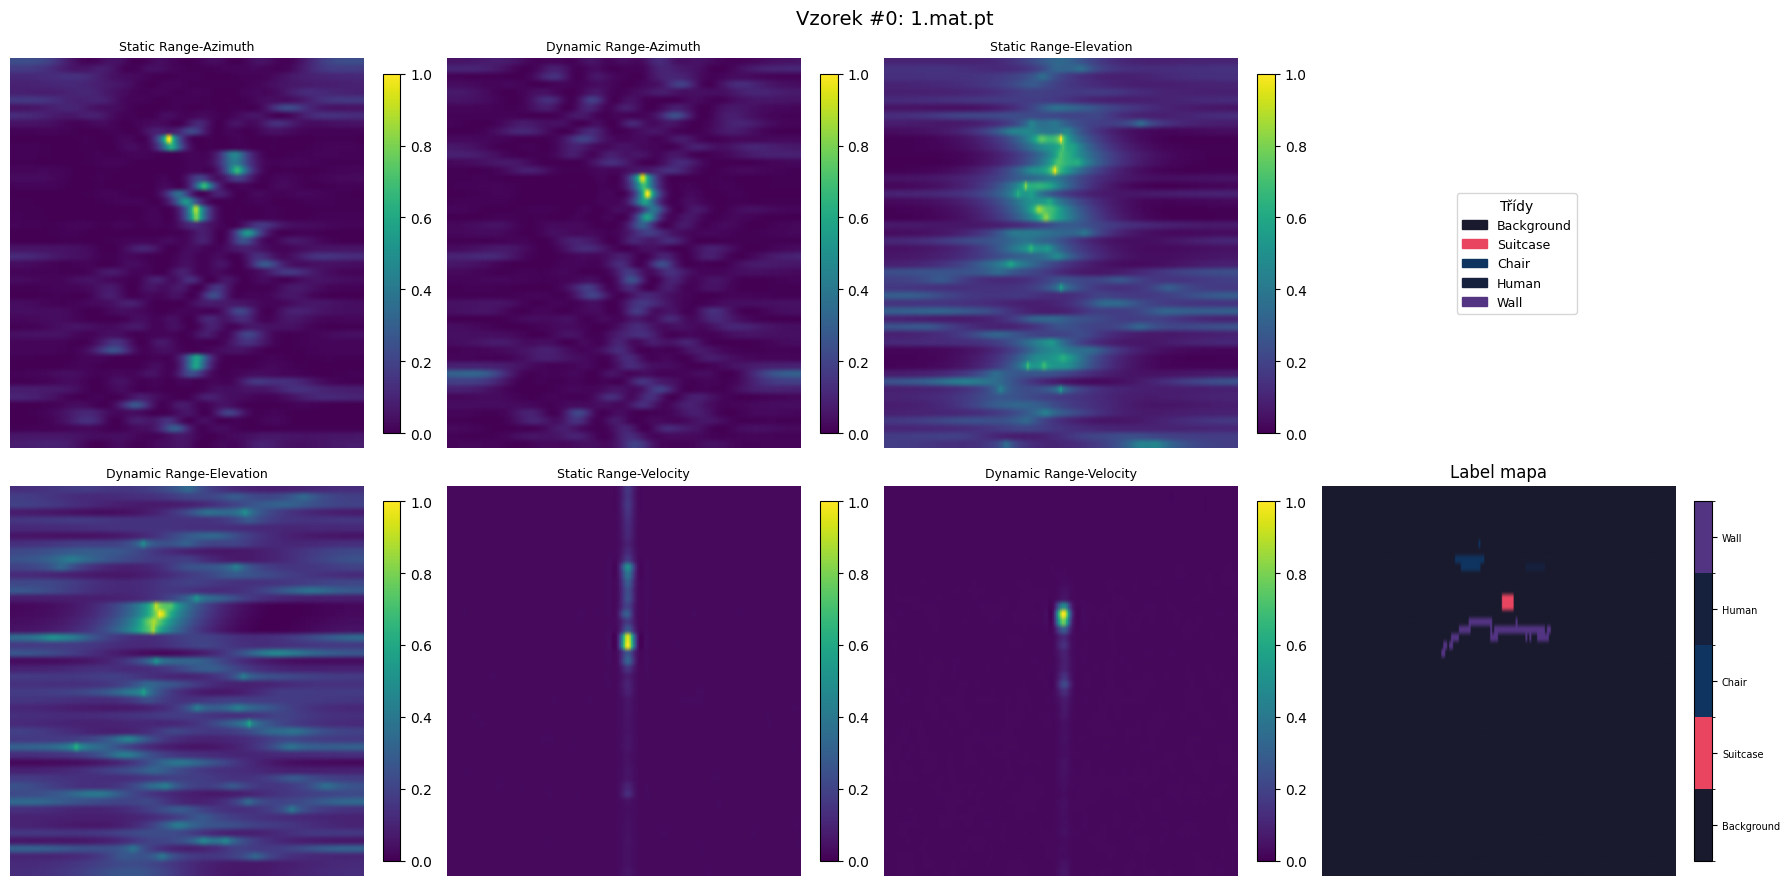


── Načítám data ──
  Načteno 1800 souborů z '/content/IOAI-2025/Individual-Contest/Radar/training_set'
  Train: 1530  |  Val (split): 270

── Inicializuji U-Net ──
  Parametry: 7,850,597
Počítám váhy tříd...
  Váhy: [0.002, 1.38, 1.167, 2.349, 0.102]

── Spouštím trénink ──
Epoch 01/20 | loss=0.5475 | IOAI val=0.8693 ★ BEST
Epoch 02/20 | loss=0.2974 | IOAI val=0.9282 ★ BEST
Epoch 03/20 | loss=0.2038 | IOAI val=0.9443 ★ BEST
Epoch 04/20 | loss=0.1573 | IOAI val=0.9541 ★ BEST
Epoch 05/20 | loss=0.1261 | IOAI val=0.9548 ★ BEST
Epoch 06/20 | loss=0.1047 | IOAI val=0.9611 ★ BEST
Epoch 07/20 | loss=0.0878 | IOAI val=0.9657 ★ BEST
Epoch 08/20 | loss=0.0789 | IOAI val=0.9640
Epoch 09/20 | loss=0.0682 | IOAI val=0.9694 ★ BEST
Epoch 10/20 | loss=0.0596 | IOAI val=0.9691
Epoch 11/20 | loss=0.0557 | IOAI val=0.9728 ★ BEST
Epoch 12/20 | loss=0.0482 | IOAI val=0.9745 ★ BEST
Epoch 13/20 | loss=0.0438 | IOAI val=0.9716
Epoch 14/20 | loss=0.0397 | IOAI val=0.9758 ★ BEST
Epoch 15/20 | loss=0.0370 | IOA

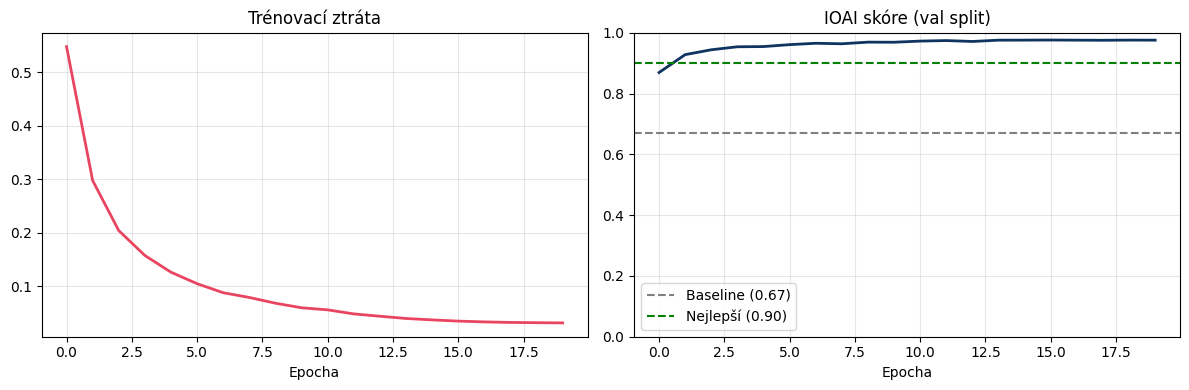

/tmp/ipykernel_6879/1359481022.py:387: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


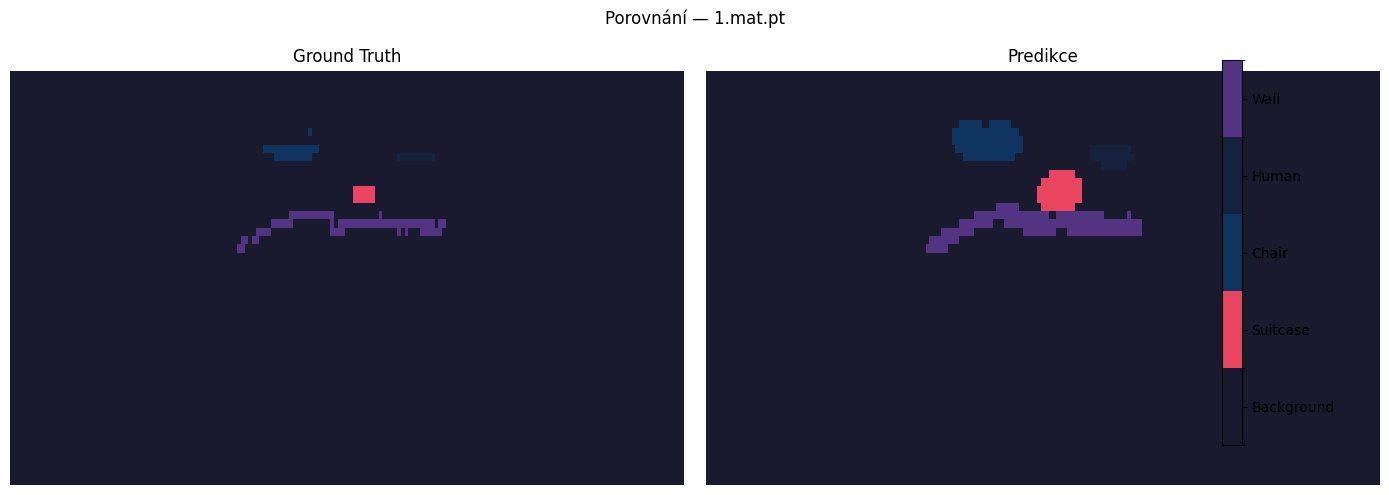

/tmp/ipykernel_6879/1359481022.py:387: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


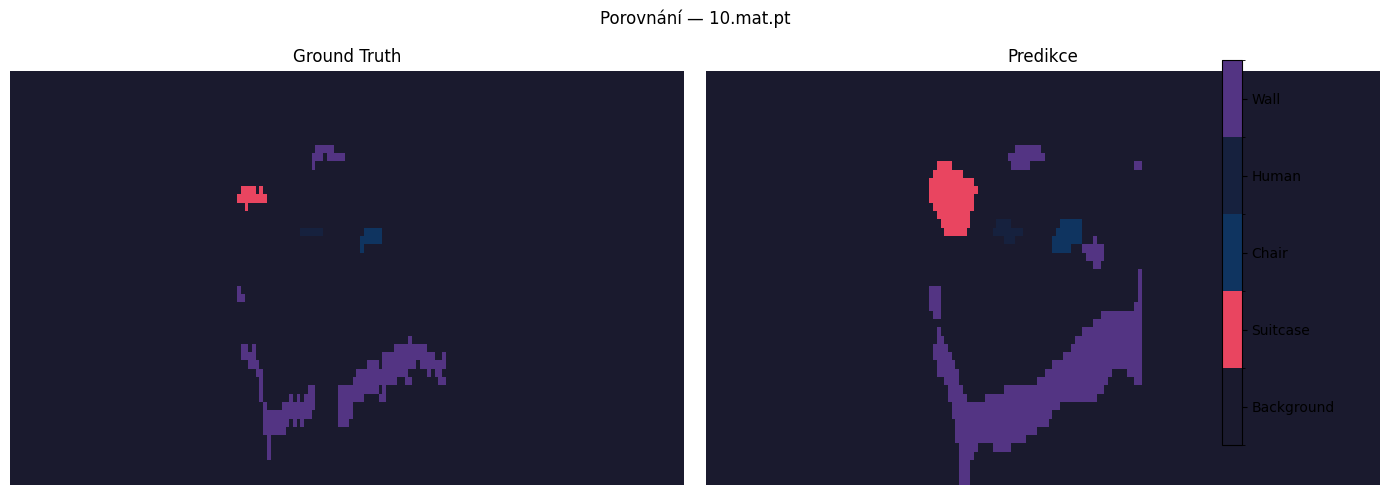

/tmp/ipykernel_6879/1359481022.py:387: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


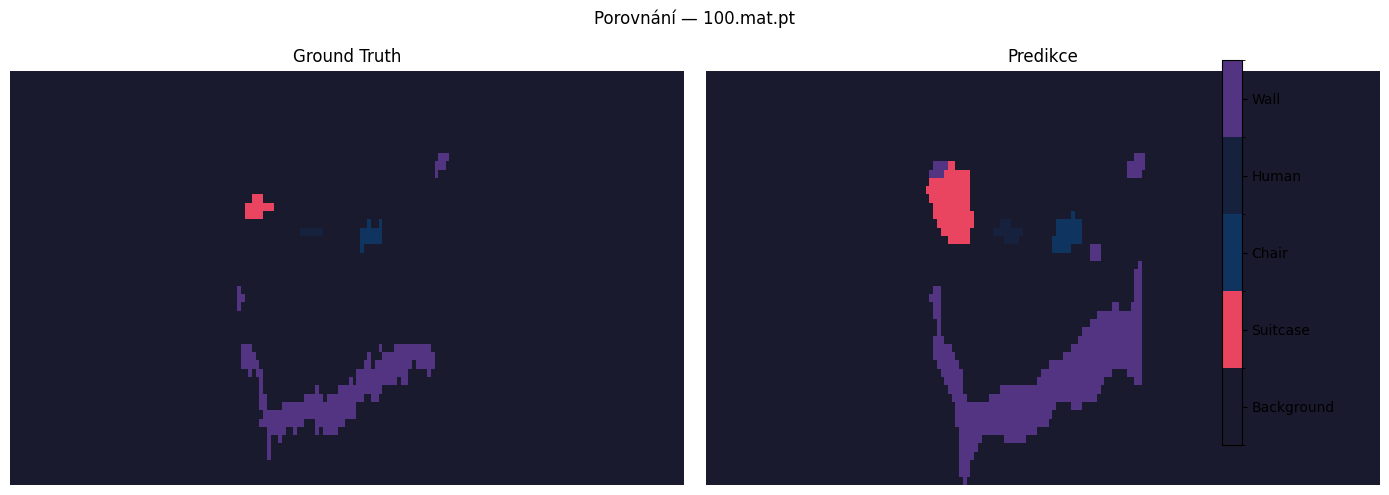


── Generuji submission ──
  Načteno 500 souborů z '/content/IOAI-2025/Individual-Contest/Radar/Solution/validation_set'
  ✓ submission_val.csv: 500 řádků, 9051 sloupců
  Načteno 500 souborů z '/content/IOAI-2025/Individual-Contest/Radar/Solution/test_set'
  ✓ submission_test.csv: 500 řádků, 9051 sloupců
✓ Hotovo: submission.zip

HOTOVO! Odevzdej soubor submission.zip


In [7]:
# ============================================================
#  Česká AI Olympiáda 2026 — AI Perception: Radar Segmentation
#  Kompletní řešení pro Google Colab (GPU runtime)
#  Cílové skóre: ~0.82–0.88
#
#  POZOR: validation_set a test_set NEMAJÍ labely (jen 6 kanálů).
#  Proto pro průběžnou validaci používáme 20% split z training setu.
# ============================================================

# Před spuštěním:
# !git clone https://github.com/IOAI-official/IOAI-2025.git

# ────────────────────────────────────────────────────────────
# SEKCE 1 — Importy
# ────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
import csv
import zipfile

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Používám: {device}")

# ────────────────────────────────────────────────────────────
# SEKCE 2 — Cesty k datům
# ────────────────────────────────────────────────────────────
BASE         = "/content/IOAI-2025/Individual-Contest/Radar"
TRAIN_FOLDER = f"{BASE}/training_set"
VAL_FOLDER   = f"{BASE}/Solution/validation_set"
TEST_FOLDER  = f"{BASE}/Solution/test_set"

# ────────────────────────────────────────────────────────────
# SEKCE 3 — Dataset
# ────────────────────────────────────────────────────────────
class RadarDataset(Dataset):
    """
    Training set — tensor shape (7, 50, 181).
    Vrací (x, y) kde y je label mapa posunutá na 0–4.
    """
    def __init__(self, folder: str):
        self.files = sorted(Path(folder).glob("*.mat.pt"))
        assert len(self.files) > 0, f"Žádné soubory v: {folder}"
        print(f"  Načteno {len(self.files)} souborů z '{folder}'")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        tensor = torch.load(self.files[idx], map_location="cpu")
        assert tensor.shape[0] == 7, f"Očekáváno 7 kanálů, nalezeno {tensor.shape[0]}"
        x = tensor[:6].float()   # (6, 50, 181)
        y = tensor[6].long() + 1 # (50, 181), posun -1..3 → 0..4
        return x, y


class RadarInferenceDataset(Dataset):
    """
    Validation / test set — tensor shape (6, 50, 181), BEZ labelů.
    Vrací (x, filename).
    """
    def __init__(self, folder: str):
        self.files = sorted(Path(folder).glob("*.mat.pt"))
        assert len(self.files) > 0, f"Žádné soubory v: {folder}"
        print(f"  Načteno {len(self.files)} souborů z '{folder}'")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        tensor = torch.load(self.files[idx], map_location="cpu")
        x = tensor[:6].float()   # (6, 50, 181)
        return x, self.files[idx].name


# ────────────────────────────────────────────────────────────
# SEKCE 4 — Vizualizace
# ────────────────────────────────────────────────────────────
CHANNEL_NAMES = [
    "Static Range-Azimuth", "Dynamic Range-Azimuth",
    "Static Range-Elevation", "Dynamic Range-Elevation",
    "Static Range-Velocity", "Dynamic Range-Velocity",
]
CLASS_NAMES  = ["Background", "Suitcase", "Chair", "Human", "Wall"]
CLASS_COLORS = ["#1a1a2e", "#e94560", "#0f3460", "#16213e", "#533483"]


def visualize_sample(folder: str, idx: int = 0):
    files  = sorted(Path(folder).glob("*.mat.pt"))
    tensor = torch.load(files[idx], map_location="cpu")
    heatmapy = tensor[:6].numpy()
    labels   = tensor[6].numpy()  # -1 až 3

    cmap_lbl = mcolors.ListedColormap(CLASS_COLORS)
    norm     = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5, 3.5], cmap_lbl.N)

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle(f"Vzorek #{idx}: {files[idx].name}", fontsize=14)

    for i in range(6):
        r, c = divmod(i, 3)
        im = axes[r][c].imshow(heatmapy[i], aspect="auto", cmap="viridis")
        axes[r][c].set_title(CHANNEL_NAMES[i], fontsize=9)
        axes[r][c].axis("off")
        plt.colorbar(im, ax=axes[r][c], fraction=0.046)

    im_lbl = axes[1][3].imshow(labels, aspect="auto", cmap=cmap_lbl, norm=norm)
    axes[1][3].set_title("Label mapa"); axes[1][3].axis("off")
    cbar = plt.colorbar(im_lbl, ax=axes[1][3], fraction=0.046, ticks=[-1,0,1,2,3])
    cbar.ax.set_yticklabels(CLASS_NAMES, fontsize=7)

    patches = [plt.Rectangle((0,0),1,1, color=CLASS_COLORS[i]) for i in range(5)]
    axes[0][3].legend(patches, CLASS_NAMES, loc="center", fontsize=9, title="Třídy")
    axes[0][3].axis("off")

    plt.tight_layout(); plt.show()


# ────────────────────────────────────────────────────────────
# SEKCE 5 — Architektura: U-Net
# ────────────────────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = ConvBlock(in_ch, out_ch)
    def forward(self, x): return self.conv(self.pool(x))


class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv = ConvBlock(in_ch + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=True)
        return self.conv(torch.cat([x, skip], dim=1))


class UNet(nn.Module):
    """
    U-Net: (B, 6, 50, 181) → (B, 5, 50, 181)
    5 výstupních tříd odpovídá hodnotám 0–4 (posun z -1..3)
    """
    def __init__(self, in_channels=6, num_classes=5, base_filters=32):
        super().__init__()
        f = base_filters
        self.enc1       = ConvBlock(in_channels, f)
        self.enc2       = Down(f,     f*2)
        self.enc3       = Down(f*2,   f*4)
        self.enc4       = Down(f*4,   f*8)
        self.bottleneck = Down(f*8,   f*16)
        self.dec4 = Up(f*16, f*8,  f*8)
        self.dec3 = Up(f*8,  f*4,  f*4)
        self.dec2 = Up(f*4,  f*2,  f*2)
        self.dec1 = Up(f*2,  f,    f)
        self.out  = nn.Conv2d(f, num_classes, 1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)
        b  = self.bottleneck(s4)
        x  = self.dec4(b,  s4)
        x  = self.dec3(x,  s3)
        x  = self.dec2(x,  s2)
        x  = self.dec1(x,  s1)
        return self.out(x)


# ────────────────────────────────────────────────────────────
# SEKCE 6 — IOAI metrika
# ────────────────────────────────────────────────────────────
def ioai_score(preds: torch.Tensor, labels: torch.Tensor) -> float:
    """preds a labels jsou v původním rozsahu -1..3."""
    bg  = (labels == -1)
    obj = (labels != -1)
    correct_bg  = ((preds == labels) & bg ).sum().item()
    correct_obj = ((preds == labels) & obj).sum().item()
    total_bg    = bg.sum().item()
    total_obj   = obj.sum().item()
    num = correct_bg * 1 + correct_obj * 50
    den = total_bg   * 1 + total_obj   * 50
    return num / den if den > 0 else 0.0


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    scores = []
    for x, y in loader:
        x, y   = x.to(device), y.to(device)
        preds  = model(x).argmax(dim=1) - 1   # [0,4] → [-1,3]
        labels = y - 1                          # [0,4] → [-1,3]
        scores.append(ioai_score(preds.cpu(), labels.cpu()))
    return float(np.mean(scores))


# ────────────────────────────────────────────────────────────
# SEKCE 7 — Váhy tříd
# ────────────────────────────────────────────────────────────
def compute_class_weights(files, num_classes=5) -> torch.Tensor:
    print("Počítám váhy tříd...")
    counts = torch.zeros(num_classes)
    for f in files:
        t = torch.load(f, map_location="cpu")
        y = (t[6] + 1).long()
        for c in range(num_classes):
            counts[c] += (y == c).sum()
    w = 1.0 / (counts + 1e-6)
    w = w / w.sum() * num_classes
    print(f"  Váhy: {[round(v, 3) for v in w.tolist()]}")
    return w


# ────────────────────────────────────────────────────────────
# SEKCE 8 — Trénink
# ────────────────────────────────────────────────────────────
def train(
    train_folder:      str   = TRAIN_FOLDER,
    val_split:         float = 0.15,       # % training dat použitých pro validaci
    epochs:            int   = 20,
    batch_size:        int   = 16,
    lr:                float = 3e-4,
    base_filters:      int   = 32,
    use_class_weights: bool  = True,
):
    # ── Data ──────────────────────────────────────────────
    print("\n── Načítám data ──")
    full_ds = RadarDataset(train_folder)

    n_val   = int(len(full_ds) * val_split)
    n_train = len(full_ds) - n_val
    train_ds, val_ds = random_split(
        full_ds, [n_train, n_val],
        generator=torch.Generator().manual_seed(42)
    )
    print(f"  Train: {n_train}  |  Val (split): {n_val}")

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)

    # ── Model ─────────────────────────────────────────────
    print("\n── Inicializuji U-Net ──")
    model = UNet(in_channels=6, num_classes=5, base_filters=base_filters).to(device)
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Parametry: {params:,}")

    # ── Loss ──────────────────────────────────────────────
    if use_class_weights:
        train_files = [full_ds.files[i] for i in train_ds.indices]
        weights = compute_class_weights(train_files).to(device)
    else:
        weights = None
    loss_fn   = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # ── Trénink ───────────────────────────────────────────
    print("\n── Spouštím trénink ──")
    best_score = 0.0
    history    = {"loss": [], "val_score": []}

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        avg_loss  = total_loss / len(train_loader)
        val_score = evaluate(model, val_loader)
        history["loss"].append(avg_loss)
        history["val_score"].append(val_score)

        marker = " ★ BEST" if val_score > best_score else ""
        if val_score > best_score:
            best_score = val_score
            torch.save(model.state_dict(), "best_model.pt")

        print(f"Epoch {epoch:02d}/{epochs} | loss={avg_loss:.4f} | IOAI val={val_score:.4f}{marker}")

    print(f"\n✓ Nejlepší IOAI skóre: {best_score:.4f}")
    return model, history


# ────────────────────────────────────────────────────────────
# SEKCE 9 — Generování submission
# ────────────────────────────────────────────────────────────
def generate_submission(model, folder: str, output_csv: str):
    ds = RadarInferenceDataset(folder)
    model.eval()

    with open(output_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["filename"] + [f"pixel_{i}" for i in range(50 * 181)])

        for x, filename in ds:
            with torch.no_grad():
                pred = model(x.unsqueeze(0).to(device)).argmax(dim=1).squeeze(0).cpu() - 1
            writer.writerow([filename] + pred.flatten().tolist())

    # Validace
    with open(output_csv) as f:
        lines = f.readlines()
    rows = len(lines) - 1
    cols = len(lines[1].split(","))
    assert rows == 500,  f"{output_csv}: čekáno 500 řádků, nalezeno {rows}"
    assert cols == 9051, f"{output_csv}: čekáno 9051 sloupců, nalezeno {cols}"
    print(f"  ✓ {output_csv}: {rows} řádků, {cols} sloupců")


def create_submission_zip(model):
    print("\n── Generuji submission ──")
    generate_submission(model, VAL_FOLDER,  "submission_val.csv")
    generate_submission(model, TEST_FOLDER, "submission_test.csv")

    with zipfile.ZipFile("submission.zip", "w") as zf:
        zf.write("submission_val.csv")
        zf.write("submission_test.csv")
    print("✓ Hotovo: submission.zip")


# ────────────────────────────────────────────────────────────
# SEKCE 10 — Vizualizace výsledků
# ────────────────────────────────────────────────────────────
def plot_training_history(history: dict):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history["loss"], color="#e94560", linewidth=2)
    ax1.set_title("Trénovací ztráta"); ax1.set_xlabel("Epocha"); ax1.grid(alpha=0.3)

    ax2.plot(history["val_score"], color="#0f3460", linewidth=2)
    ax2.axhline(0.67, color="gray",  linestyle="--", label="Baseline (0.67)")
    ax2.axhline(0.90, color="green", linestyle="--", label="Nejlepší (0.90)")
    ax2.set_title("IOAI skóre (val split)"); ax2.set_xlabel("Epocha")
    ax2.legend(); ax2.grid(alpha=0.3); ax2.set_ylim(0, 1)
    plt.tight_layout(); plt.show()


def visualize_predictions(model, folder: str, idx: int = 0):
    files  = sorted(Path(folder).glob("*.mat.pt"))
    tensor = torch.load(files[idx], map_location="cpu")
    x      = tensor[:6].float().unsqueeze(0).to(device)
    gt     = tensor[6].numpy()

    with torch.no_grad():
        pred = model(x).argmax(dim=1).squeeze(0).cpu().numpy() - 1

    cmap = mcolors.ListedColormap(CLASS_COLORS)
    norm = mcolors.BoundaryNorm([-1.5,-0.5,0.5,1.5,2.5,3.5], cmap.N)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Porovnání — {files[idx].name}")
    ax1.imshow(gt,   cmap=cmap, norm=norm, aspect="auto"); ax1.set_title("Ground Truth"); ax1.axis("off")
    im = ax2.imshow(pred, cmap=cmap, norm=norm, aspect="auto"); ax2.set_title("Predikce"); ax2.axis("off")
    cbar = fig.colorbar(im, ax=[ax1, ax2], ticks=[-1,0,1,2,3], fraction=0.03)
    cbar.ax.set_yticklabels(CLASS_NAMES)
    plt.tight_layout(); plt.show()


# ────────────────────────────────────────────────────────────
# SEKCE 11 — MAIN
# ────────────────────────────────────────────────────────────
if __name__ == "__main__":

    # 1. Vizualizace
    visualize_sample(TRAIN_FOLDER, idx=0)

    # 2. Trénink (validace probíhá na 15% splitu z training setu)
    model, history = train(
        train_folder      = TRAIN_FOLDER,
        val_split         = 0.15,
        epochs            = 20,
        batch_size        = 16,
        lr                = 3e-4,
        base_filters      = 32,
        use_class_weights = True,
    )

    # 3. Načtení nejlepšího checkpointu
    model.load_state_dict(torch.load("best_model.pt", map_location=device))
    print("✓ Načten best_model.pt")

    # 4. Grafy
    plot_training_history(history)

    # 5. Ukázka predikcí (z training setu, kde máme ground truth)
    for i in range(3):
        visualize_predictions(model, TRAIN_FOLDER, idx=i)

    # 6. Submission
    create_submission_zip(model)

    print("\n" + "="*50)
    print("HOTOVO! Odevzdej soubor submission.zip")
    print("="*50)
